In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the Excel file
# file_path = 'dv0_witoutstraw.xlsx'  
file_path = 'dv0_withoutstraw_sipCAdded.xlsx' # Use the correct path for your environment
data = pd.read_excel(file_path)
# print("Columns in the dataset:")
# print(data.columns.tolist())
# Display the first few rows of the dataset to understand its structure
# print("Original Data Sample:")

df = data[data['Label'] == 1]
df['Gender'] = df["Gender"].map({"Male": 1, "Female": 0})

df["Container_Weight"] = df["Container_Weight"].map({
    7.7: 0,
    10.6: 1,
    10.9: 1,  
    12.7: 2,
    19.8: 3,
    359: 4
})
# df["Container_Weight"] = df["Container_Weight"].map({
#     7.7: 0,   # First type.  water plastic bottle
#     10.6: 1,  # Second type. paper cup 
#     10.9: 2,  # Changed this to represent a distinct type- paper cup
#     12.7: 3,  # Third type. cup plastic
#     19.8: 4,  # Fourth type bottle coke
#     359: 5    # Fifth type mug
# })
df["Label"] = df["Label"].map({"Drinking": 1, "Not_Drinking": 0})
df['temp'] = df ['temp'].map({'h':2, 'c':0, 'n': 1})
# print(data.head())
# Group by Participant_ID and sip_id to count time steps and extract dV and Label
grouped_data = df.groupby(['Participant_ID', 'sip_id']).agg(
    time_steps=('sip_id', 'size'),  # Count of rows (time steps)
    dV=('dV', 'first'),  # Taking the first dV value for each group
    Gender=('Gender', 'first'), 
    temp=('temp', 'first') ,
    Container_Weight=('Container_Weight', 'first'),
    Label=('Label', 'first')  # Assuming the label is consistent, take the first
).reset_index()


# Merge SIP_TIME back to the grouped data
# grouped_data = pd.merge(grouped_data, sip_counts, on='sip_id', how='left').fillna(0)
# grouped_data['SIP_TIME'] = grouped_data['SIP_TIME'].astype(int)
# Display the grouped data before creating X and y
print("\nGrouped Data Sample:")
print(grouped_data.head(200))
# grouped_data.to_excel('dv0_witoutstraw_final.xlsx')
# Prepare features (X) and target (y)
X = grouped_data[['time_steps','Gender', 'Container_Weight','temp', 'sip_id']]  # Features
y = grouped_data['dV']             # Target variable

# Display X and y before proceeding
print("\nFeatures (X):")
print(X.head(50))
print("\nTarget (y):")
print(y.head(50))

# Split the data into training and testing sets (optional)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now you can proceed with training your model using X and y as needed


Grouped Data Sample:
     Participant_ID  sip_id  time_steps          dV  Gender  temp  \
0                 6       1          26   69.904762       1     0   
1                 6       2          26   58.000000       1     0   
2                 6       3          27   61.904762       1     0   
3                 6       4          29   68.857143       1     0   
4                 6       5          23   44.571429       1     0   
..              ...     ...         ...         ...     ...   ...   
195              36      16          16   36.630754       1     0   
196              36      17          14   28.795299       1     0   
197              37       1          20  129.300000       0     1   
198              37       2          23  160.200000       0     1   
199              37       3          22  141.600000       0     1   

     Container_Weight  Label  
0                   3    NaN  
1                   3    NaN  
2                   3    NaN  
3                   3    

/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_2573/3591649810.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = df["Gender"].map({"Male": 1, "Female": 0})
/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_2573/3591649810.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Container_Weight"] = df["Container_Weight"].map({
/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_2573/3591649810.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy

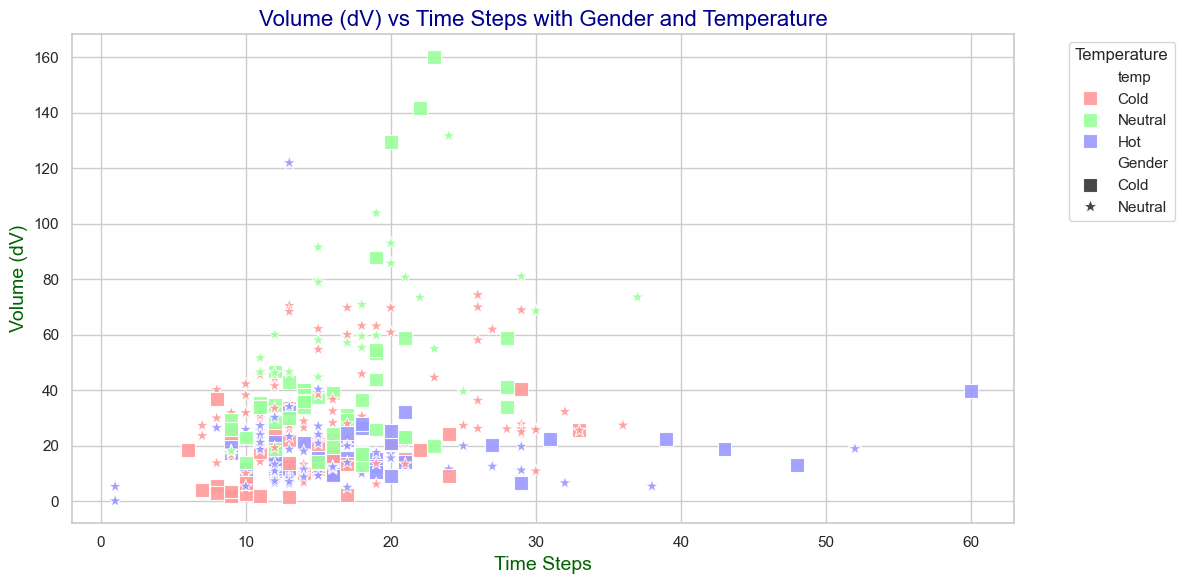

KeyError: 3

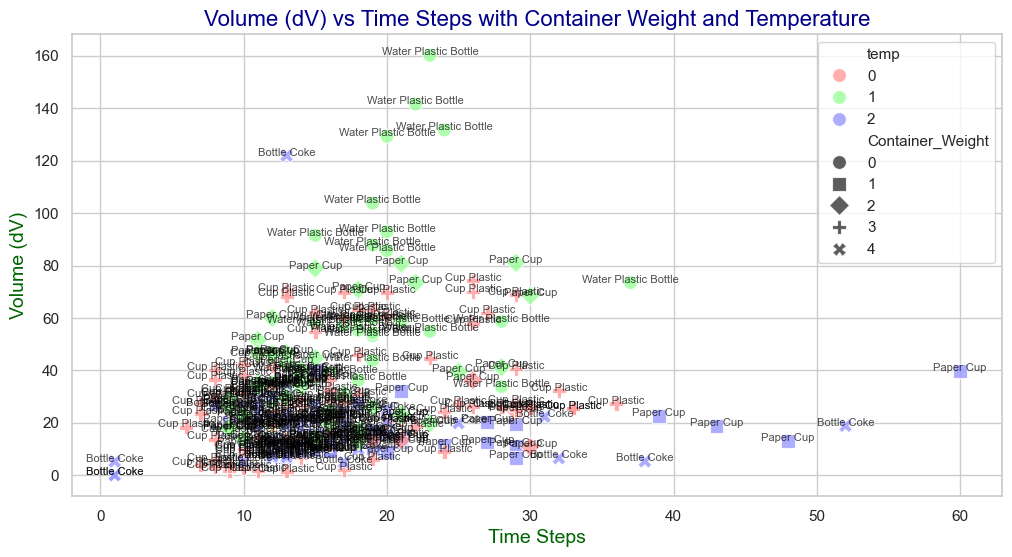

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Container Weight Color Palette with Distinct Colors
container_weight_palette = {
    0: '#1f77b4',   # Color for Container_Weight = 0 (Water Plastic Bottle)
    1: '#ff7f0e',   # Color for Container_Weight = 1 (Paper Cup)
    2: '#2ca02c',   # Color for Container_Weight = 2 (Paper Cup)
    3: '#d62728',   # Color for Container_Weight = 3 (Cup Plastic)
    4: '#9467bd',   # Color for Container_Weight = 4 (Bottle Coke)
}

# Temperature Color Palette with Brighter Colors
temp_palette = {
    0: '#ff9999',  # Color for temp = 0 (Cold)
    1: '#99ff99',  # Color for temp = 1 (Neutral)
    2: '#9999ff'   # Color for temp = 2 (Hot)
}

# Create distinct markers for Gender
markers = {0: "s", 1: "*"}  # 0: Female (square), 1: Male (star)

# Create a mapping for temperature labels
temp_labels = {0: "Cold", 1: "Neutral", 2: "Hot"}

# Create a scatter plot of volume (dV) vs time_steps by gender
plt.figure(figsize=(12, 6))
sns.scatterplot(data=grouped_data, 
                x='time_steps', 
                y='dV', 
                hue='temp',               # Hue based on Temperature
                palette=temp_palette,     # Use the temp color palette
                style='Gender',           # Different markers for Gender
                markers=markers, 
                legend='full',
                s=100,                    # Increase marker size for visibility
                alpha=0.9,                # Adjust transparency
                edgecolor='w')            # Add edge color for better visibility

# Adding custom legend for temperature labels
handles, labels = plt.gca().get_legend_handles_labels()
# Update the labels to be more descriptive
new_labels = [temp_labels[int(label)] if label.isdigit() else label for label in labels]
plt.legend(handles=handles, labels=new_labels, title='Temperature', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adding titles and labels with colors for visibility
plt.title("Volume (dV) vs Time Steps with Gender and Temperature", fontsize=16, color='darkblue')
plt.xlabel("Time Steps", fontsize=14, color='darkgreen')
plt.ylabel("Volume (dV)", fontsize=14, color='darkgreen')

# Show the plot
plt.tight_layout()
plt.show()

# Create a new scatter plot of volume (dV) vs time_steps by container weight
plt.figure(figsize=(12, 6))

# Assign distinct markers for each container weight
container_markers = {
    0: "o",  # Water Plastic Bottle
    1: "s",  # Paper Cup
    2: "D",  # Paper Cup
    3: "P",  # Cup Plastic
    4: "X"   # Bottle Coke
}

# Create a mapping for container labels
container_labels = {
    0: "Water Plastic Bottle",
    1: "Paper Cup",
    2: "Paper Cup",
    3: "Cup Plastic",
    4: "Bottle Coke"
}

# Scatter plot with Container Weight and Temperature
sns.scatterplot(data=grouped_data, 
                x='time_steps', 
                y='dV', 
                hue='temp',                # Hue based on Temperature
                palette=temp_palette,      # Use the temp color palette
                style='Container_Weight',  # Different markers for Container Weight
                markers=container_markers,  # Assign different markers
                legend='full',
                s=100,                    # Increase marker size for visibility
                alpha=0.8,                # Adjust transparency
                edgecolor='w')            # Add edge color for better visibility

# Adding annotations for container labels
for i, row in grouped_data.iterrows():
    plt.text(row['time_steps'], row['dV'], container_labels[row['Container_Weight']],
             horizontalalignment='center', fontsize=8, alpha=0.7, color='black')

# Adding titles and labels with colors for visibility
plt.title("Volume (dV) vs Time Steps with Container Weight and Temperature", fontsize=16, color='darkblue')
plt.xlabel("Time Steps", fontsize=14, color='darkgreen')
plt.ylabel("Volume (dV)", fontsize=14, color='darkgreen')

# Customize the legend for better visibility
handles, labels = plt.gca().get_legend_handles_labels()
# Update the labels to be more descriptive for temperature
new_labels = [temp_labels[int(label)] if label.isdigit() else label for label in labels]
plt.legend(handles=handles, labels=new_labels, title='Temperature', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the second plot
plt.tight_layout()
plt.show()

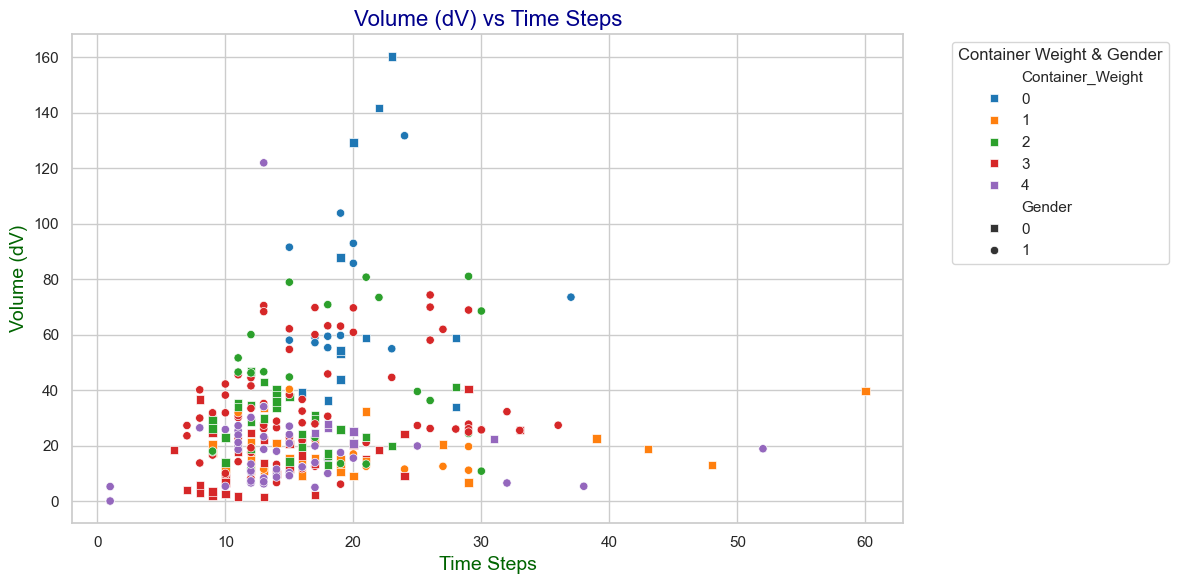

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Create a custom color palette for Container Weight
container_weight_palette = {
    0: '#1f77b4',  # Color for Container_Weight = 0
    1: '#ff7f0e',  # Color for Container_Weight = 1
    2: '#2ca02c',  # Color for Container_Weight = 2
    3: '#d62728',  # Color for Container_Weight = 3
    4: '#9467bd',  # Color for Container_Weight = 4
}

# Create markers for Male (1) and Female (0)
markers = {0: "s", 1: "o"}  # 0: Female, 1: Male based on the previous mapping

# Create a scatter plot of volume (dV) vs time_steps
plt.figure(figsize=(12, 6))

# Scatter plot for Container Weight
sns.scatterplot(data=grouped_data, 
                x='time_steps', y='dV', 
                hue='Container_Weight', 
                palette=container_weight_palette,
                style='Gender', 
                markers=markers,  # Use updated markers
                legend='full')

# Adding titles and labels with colors for visibility
plt.title("Volume (dV) vs Time Steps", fontsize=16, color='darkblue')
plt.xlabel("Time Steps", fontsize=14, color='darkgreen')
plt.ylabel("Volume (dV)", fontsize=14, color='darkgreen')

# Customize the legend for better visibility
plt.legend(title='Container Weight & Gender', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()

In [2]:
# Check for time_steps equal to zero
zero_time_steps_mask = grouped_data['dV'] == 0  # Creates a boolean mask
zero_time_steps_indices = grouped_data.index[zero_time_steps_mask].tolist()  # Get indices of rows where time_steps is zero
zero_time_steps_count = zero_time_steps_mask.sum()  # Count how many are True in the mask

# Display results
print(f"\nIndices where time_steps are 0: {zero_time_steps_indices}")
print(f"Total number of time_steps that are 0: {zero_time_steps_count}")


Indices where time_steps are 0: [222, 223]
Total number of time_steps that are 0: 2


In [3]:
# Retrieve the records from grouped_data using the identified indices
zero_time_steps_records = grouped_data.loc[zero_time_steps_indices]

# Get the Participant_ID and sip_id
participant_ids_and_sip_ids = zero_time_steps_records[['Participant_ID', 'sip_id']]

# Display the result
print("\nRecords with zero time_steps:")
print(participant_ids_and_sip_ids)


Records with zero time_steps:
     Participant_ID  sip_id
222              40      14
223              40      15


In [87]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
# from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor

In [88]:
train_size = int(0.8 * len(grouped_data))  # 80% of the data for training
X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]
X_test = X.iloc[train_size:]
y_test = y.iloc[train_size:]


In [10]:

# Create a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)




In [7]:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [8]:
model = SVR(kernel='poly')
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [9]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [10]:
model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [11]:
model = XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

NameError: name 'XGBRegressor' is not defined

In [ ]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

# Print evaluation metrics
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison_df.head(50))
# Plot Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual vs Predicted Drinking Volume')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# plt.figure(figsize=(10, 6))
# plt.scatter(X, y, color='blue', label='Predicted vs Actual', alpha=0.6)
# # plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
# plt.xlabel('timestamp')
# plt.ylabel('Volume')
# plt.title('All data plot')
# plt.legend()
# plt.grid()
# plt.show()

Explained Variance by Principal Components:
Principal Component 1: 0.8090
Principal Component 2: 0.1910

Linear Regression Evaluation Metrics:
Mean Squared Error (MSE): 366.8778
Root Mean Squared Error (RMSE): 19.1541
R-squared (R²): -0.1666
Root Mean Squared Percentage Error (RMSPE): 78.1181%
     Actual  Predicted
252    36.0  23.846279
253    33.7  22.472020
254    23.0  25.459994
255    13.9  17.230795
256    17.7  30.320249


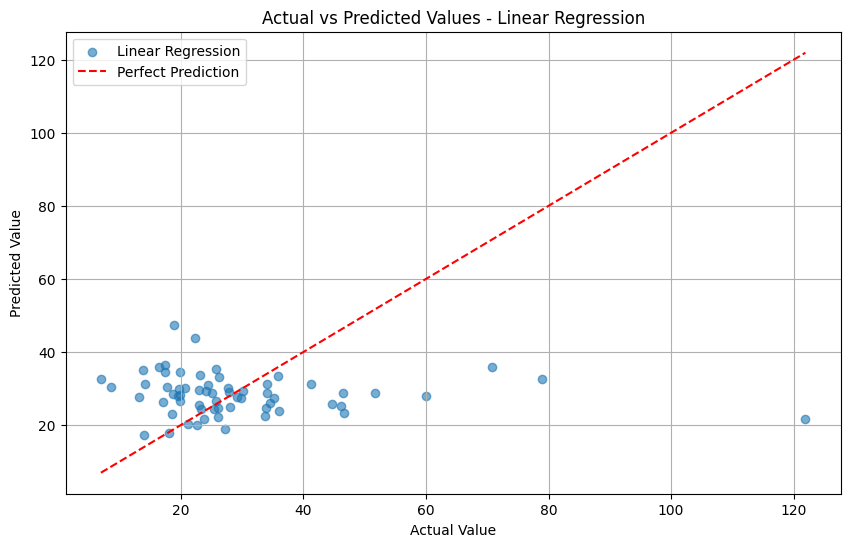


Support Vector Regression Evaluation Metrics:
Mean Squared Error (MSE): 398.9984
Root Mean Squared Error (RMSE): 19.9749
R-squared (R²): -0.2687
Root Mean Squared Percentage Error (RMSPE): 51.9695%
     Actual  Predicted
252    36.0  19.396495
253    33.7  18.841170
254    23.0  22.976302
255    13.9  18.139807
256    17.7  19.723256


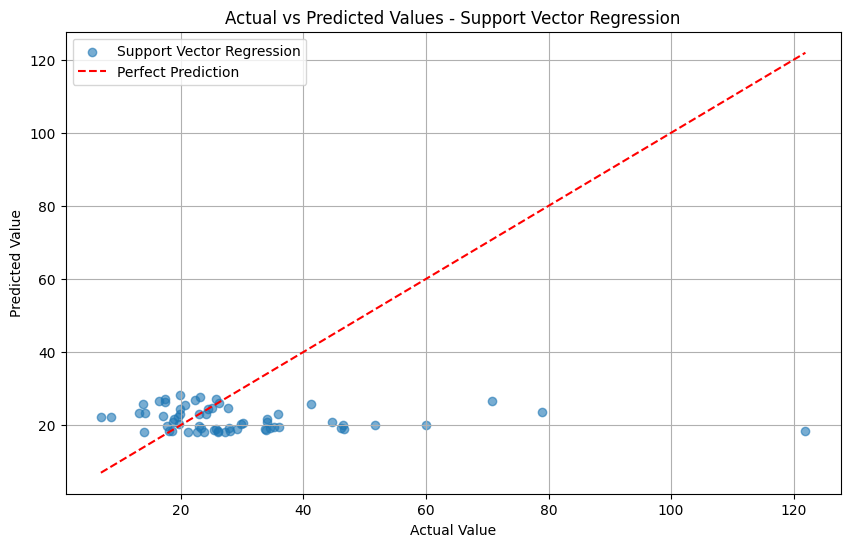


Decision Tree Evaluation Metrics:
Mean Squared Error (MSE): 751.2232
Root Mean Squared Error (RMSE): 27.4085
R-squared (R²): -1.3886
Root Mean Squared Percentage Error (RMSPE): 122.0524%
     Actual  Predicted
252    36.0  11.428571
253    33.7   6.206897
254    23.0  58.700000
255    13.9  31.809524
256    17.7   2.644466


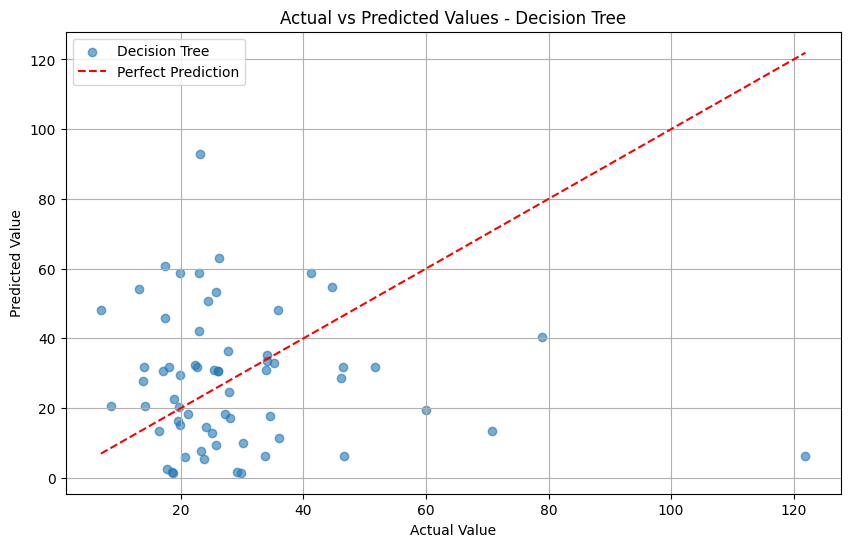


Random Forest Evaluation Metrics:
Mean Squared Error (MSE): 505.1492
Root Mean Squared Error (RMSE): 22.4755
R-squared (R²): -0.6062
Root Mean Squared Percentage Error (RMSPE): 97.6899%
     Actual  Predicted
252    36.0  22.590185
253    33.7  25.164249
254    23.0  53.569250
255    13.9  23.530833
256    17.7  12.286891


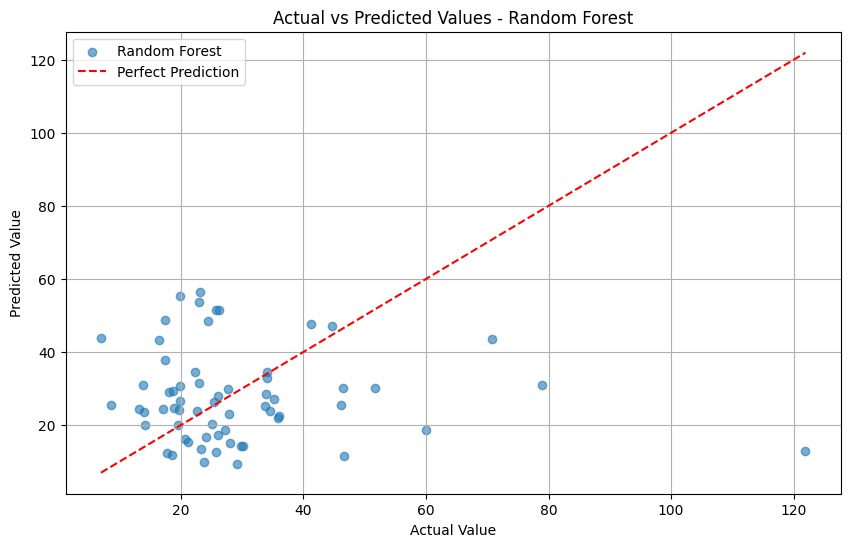


Gradient Boosting Evaluation Metrics:
Mean Squared Error (MSE): 497.2562
Root Mean Squared Error (RMSE): 22.2992
R-squared (R²): -0.5811
Root Mean Squared Percentage Error (RMSPE): 98.1416%
     Actual  Predicted
252    36.0  22.219653
253    33.7  21.517989
254    23.0  46.029750
255    13.9  16.864431
256    17.7   9.380714


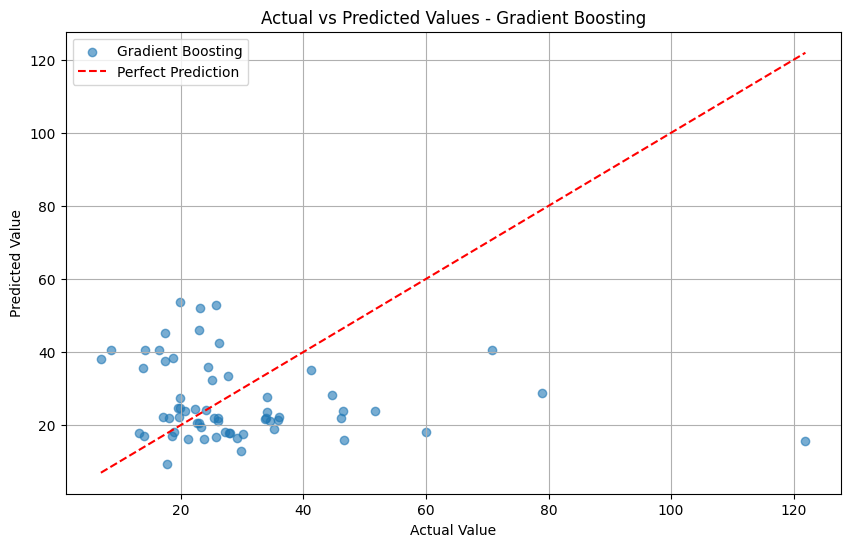


K-Nearest Neighbors Evaluation Metrics:
Mean Squared Error (MSE): 444.5312
Root Mean Squared Error (RMSE): 21.0839
R-squared (R²): -0.4135
Root Mean Squared Percentage Error (RMSPE): 74.9839%
     Actual  Predicted
252    36.0  23.637077
253    33.7  16.913969
254    23.0  31.458294
255    13.9  22.158103
256    17.7  23.722569


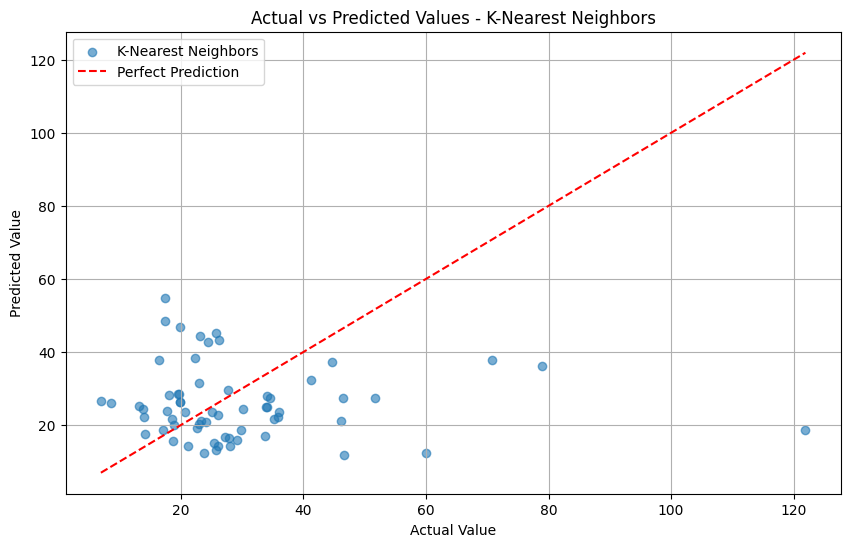


PCA Loadings:
                PC1      PC2
Feature 1  7.690986  0.00000
Feature 2  0.000000  3.73743


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA

# Assuming X_train, X_test, y_train, y_test are already defined

# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regression": SVR(kernel='rbf'),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
}

# Store evaluation results
results = {}

# Fit PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Print explained variance
print("Explained Variance by Principal Components:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Principal Component {i + 1}: {var:.4f}")

# Model evaluation
for model_name, model in models.items():
    # Fit the model
    model.fit(X_train_pca, y_train)

    # Make predictions
    y_pred = model.predict(X_test_pca)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

    # Store results in a dictionary
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R^2': r2,
        'RMSPE': rmspe,
        'Predictions': y_pred
    }

    # Print evaluation metrics for the model
    print(f"\n{model_name} Evaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R²): {r2:.4f}")
    print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

    # Create a comparison DataFrame for the first few rows
    comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
    print(comparison_df.head(5))

    # Plotting Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, label=model_name, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
    plt.xlabel('Actual Value')
    plt.ylabel('Predicted Value')
    plt.title(f'Actual vs Predicted Values - {model_name}')
    plt.legend()
    plt.grid()
    plt.show()

# Analyzing Loadings of PCA

# Determine if X_train is a DataFrame or a NumPy array
if isinstance(X_train, pd.DataFrame):
    feature_names = X_train.columns
else:
    # If X_train is a NumPy array, you can use default feature names (e.g., "Feature 1", "Feature 2", ...)
    feature_names = [f'Feature {i+1}' for i in range(X_train.shape[1])]

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loading_df = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(pca.components_.shape[0])], index=feature_names)

print("\nPCA Loadings:")
print(loading_df)

In [81]:
# Assuming X_train is your original feature set

# Fit PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Print explained variance
print("Explained Variance by Principal Components:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Principal Component {i + 1}: {var:.4f}")

# Analyzing Loadings of PCA

# Use the column names from the original DataFrame
if isinstance(X_train, pd.DataFrame):
    feature_names = X_train.columns.tolist()
else:
    # If it's a NumPy array, generate default names
    feature_names = [f'Feature {i + 1}' for i in range(X_train.shape[1])]

# Calculate the loadings
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)  # Loadings calculated as explained variance
loading_df = pd.DataFrame(loadings, columns=[f'PC{i + 1}' for i in range(pca.components_.shape[0])], index=feature_names)

# Display peak contributions
print("\nPCA Loadings:")
print(loading_df)

# Optional: To better understand which features contribute to each component
print("\nContribution of Features to Principal Components (sorted):")
for i in range(loadings.shape[1]):
    print(f"Principal Component {i + 1}:")
    sorted_indices = np.argsort(np.abs(loadings[:, i]))[::-1]  # Sort by absolute value
    for index in sorted_indices:
        print(f"{feature_names[index]}: {loadings[index, i]:.4f}")

Explained Variance by Principal Components:
Principal Component 1: 0.8090
Principal Component 2: 0.1910

PCA Loadings:
                PC1      PC2
Feature 1  7.690986  0.00000
Feature 2  0.000000  3.73743

Contribution of Features to Principal Components (sorted):
Principal Component 1:
Feature 1: 7.6910
Feature 2: 0.0000
Principal Component 2:
Feature 2: 3.7374
Feature 1: 0.0000


In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

# Sample DataFrame with 4 features for demonstration
features = df[['time_steps', 'Gender', 'Container_Weight', 'temp', 'sip_id']]

# Optional: Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Fit PCA
pca = PCA(n_components=2)  # Adjust n_components as needed
X_pca = pca.fit_transform(features_scaled)

# Print explained variance
print("Explained Variance by Principal Components:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Principal Component {i + 1}: {var:.4f}")

# Loading results
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loading_df = pd.DataFrame(loadings, index=features.columns, columns=[f'PC{i + 1}' for i in range(loadings.shape[1])])

# Display PCA Loadings
print("\nPCA Loadings:")
print(loading_df)

# Contribution of Features to Principal Components
print("\nContribution of Features to Principal Components (sorted):")
for i in range(loadings.shape[1]):
    print(f"\nPrincipal Component {i + 1}:")
    sorted_indices = np.argsort(np.abs(loadings[:, i]))[::-1]  # Sort by absolute loading values
    for index in sorted_indices:
        print(f"{features.columns[index]}: {loadings[index, i]:.4f}")

# Optional: Visualize the PCA results
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, label='PCA Projection')
plt.title('PCA of Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid()
plt.legend()
plt.show()

KeyError: "['time_steps'] not in index"


Linear Regression Evaluation Metrics:
Mean Squared Error (MSE): 366.8778
Root Mean Squared Error (RMSE): 19.1541
R-squared (R²): -0.1666
Root Mean Squared Percentage Error (RMSPE): 78.1181%
     Actual  Predicted
252    36.0  23.846279
253    33.7  22.472020
254    23.0  25.459994
255    13.9  17.230795
256    17.7  30.320249


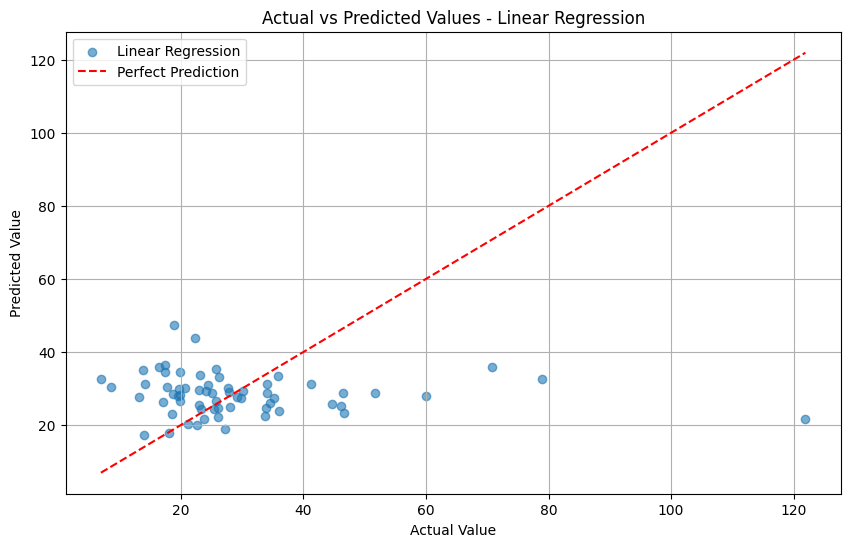


Support Vector Regression Evaluation Metrics:
Mean Squared Error (MSE): 398.9984
Root Mean Squared Error (RMSE): 19.9749
R-squared (R²): -0.2687
Root Mean Squared Percentage Error (RMSPE): 51.9695%
     Actual  Predicted
252    36.0  19.396495
253    33.7  18.841170
254    23.0  22.976302
255    13.9  18.139807
256    17.7  19.723256


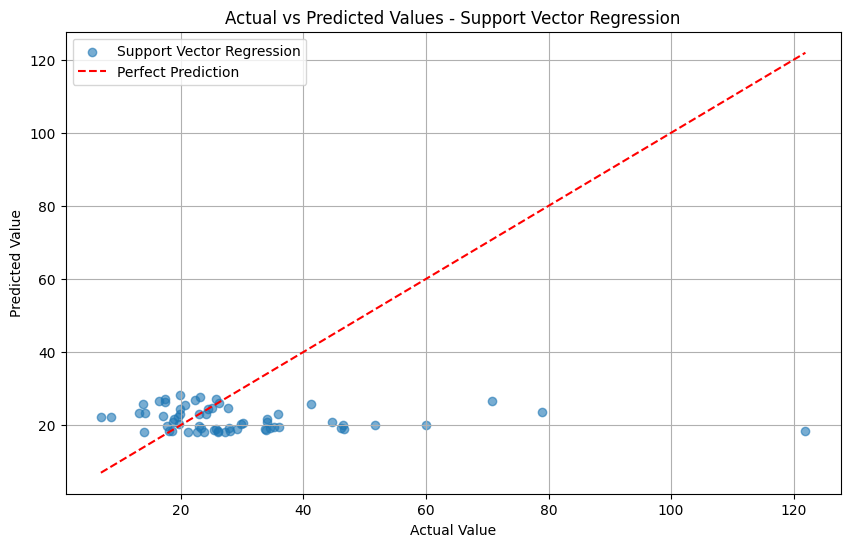


Decision Tree Evaluation Metrics:
Mean Squared Error (MSE): 751.2232
Root Mean Squared Error (RMSE): 27.4085
R-squared (R²): -1.3886
Root Mean Squared Percentage Error (RMSPE): 122.0524%
     Actual  Predicted
252    36.0  11.428571
253    33.7   6.206897
254    23.0  58.700000
255    13.9  31.809524
256    17.7   2.644466


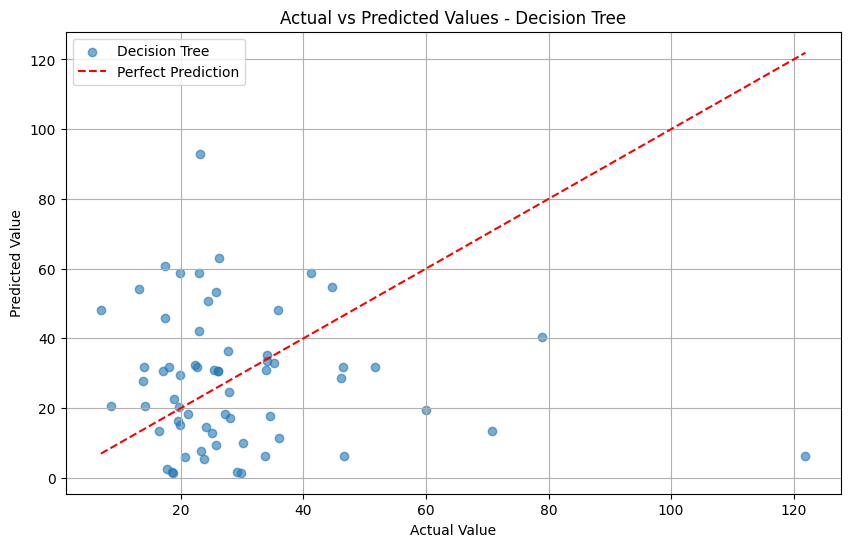


Random Forest Evaluation Metrics:
Mean Squared Error (MSE): 505.1492
Root Mean Squared Error (RMSE): 22.4755
R-squared (R²): -0.6062
Root Mean Squared Percentage Error (RMSPE): 97.6899%
     Actual  Predicted
252    36.0  22.590185
253    33.7  25.164249
254    23.0  53.569250
255    13.9  23.530833
256    17.7  12.286891


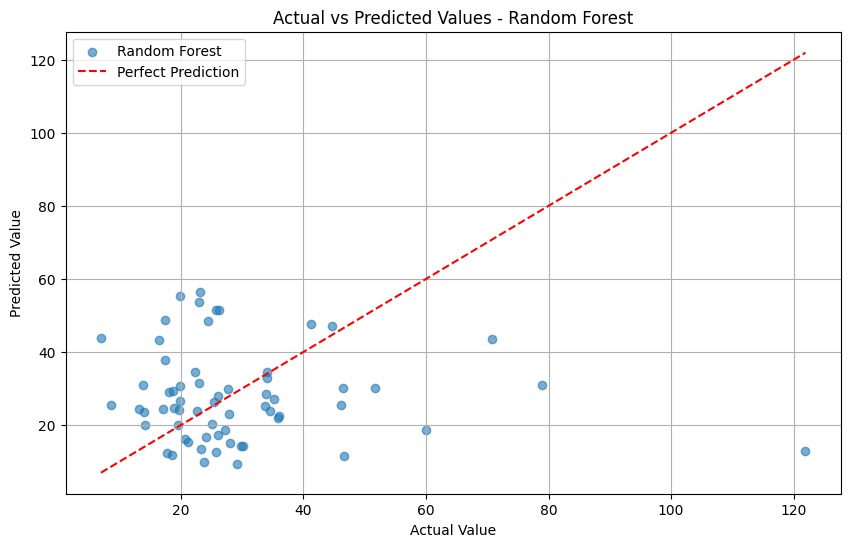


Gradient Boosting Evaluation Metrics:
Mean Squared Error (MSE): 497.2562
Root Mean Squared Error (RMSE): 22.2992
R-squared (R²): -0.5811
Root Mean Squared Percentage Error (RMSPE): 98.1416%
     Actual  Predicted
252    36.0  22.219653
253    33.7  21.517989
254    23.0  46.029750
255    13.9  16.864431
256    17.7   9.380714


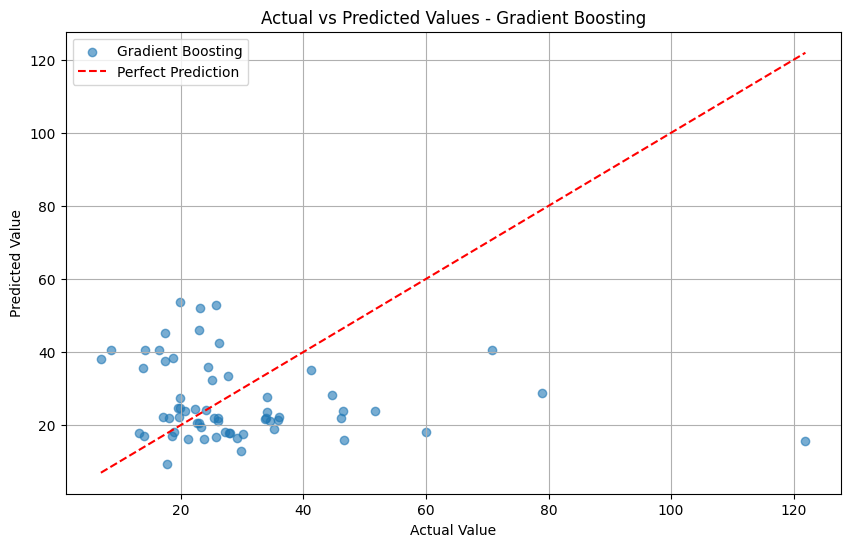


K-Nearest Neighbors Evaluation Metrics:
Mean Squared Error (MSE): 444.5312
Root Mean Squared Error (RMSE): 21.0839
R-squared (R²): -0.4135
Root Mean Squared Percentage Error (RMSPE): 74.9839%
     Actual  Predicted
252    36.0  23.637077
253    33.7  16.913969
254    23.0  31.458294
255    13.9  22.158103
256    17.7  23.722569


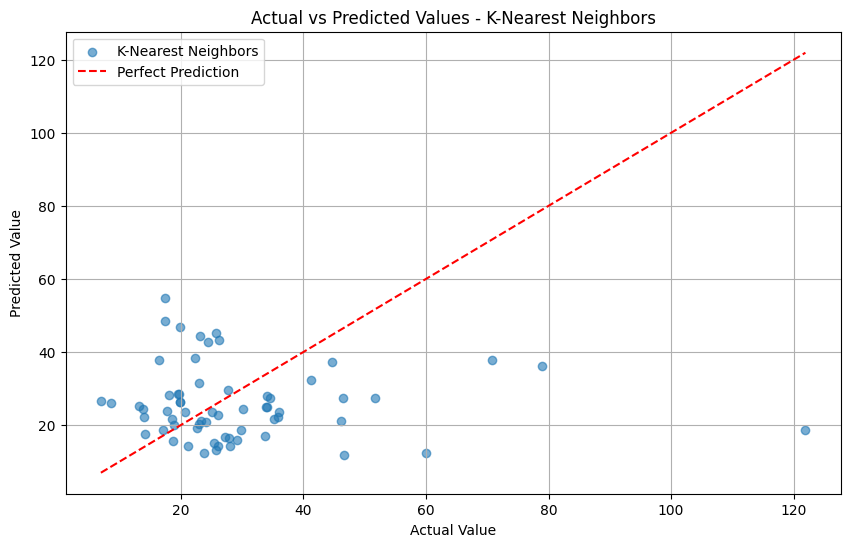

In [78]:
models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regression": SVR(kernel='rbf'),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    # "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
}

# Store evaluation results
results = {}

for model_name, model in models.items():
    # Fit the model
    from sklearn.decomposition import PCA

    pca = PCA(n_components=2)

    X_train = pca.fit_transform(X_train)
    X_test = pca.transform(X_test)
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

    # Store results in a dictionary
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R^2': r2,
        'RMSPE': rmspe,
        'Predictions': y_pred
    }

    # Print evaluation metrics for the model
    print(f"\n{model_name} Evaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R²): {r2:.4f}")
    print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

    # Create a comparison DataFrame for the first few rows
    comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
    print(comparison_df.head(5))

    # Plotting Actual vs Predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, label=model_name, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
    plt.xlabel('Actual Value')
    plt.ylabel('Predicted Value')
    plt.title(f'Actual vs Predicted Values - {model_name}')
    plt.legend()
    plt.grid()
    plt.show()


Linear Regression Evaluation Metrics:
Mean Squared Error (MSE): 500.9922
Root Mean Squared Error (RMSE): 22.3829
R-squared (R²): -0.6121
Root Mean Squared Percentage Error (RMSPE): 62.2958%


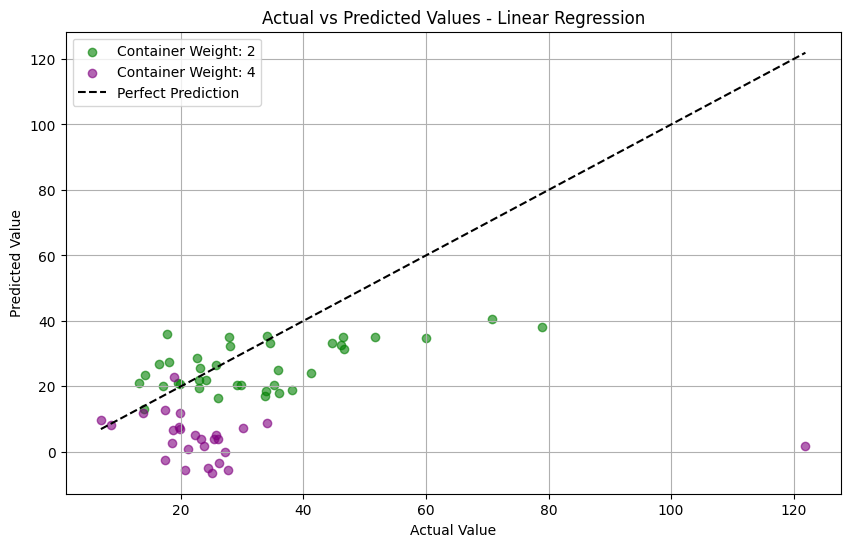


Support Vector Regression Evaluation Metrics:
Mean Squared Error (MSE): 398.6271
Root Mean Squared Error (RMSE): 19.9656
R-squared (R²): -0.2827
Root Mean Squared Percentage Error (RMSPE): 47.9482%


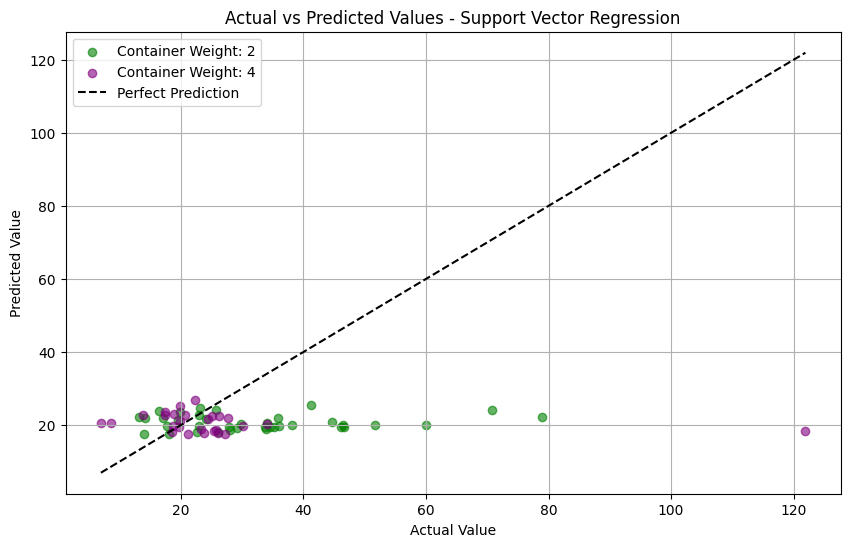


Decision Tree Evaluation Metrics:
Mean Squared Error (MSE): 731.4507
Root Mean Squared Error (RMSE): 27.0453
R-squared (R²): -1.3537
Root Mean Squared Percentage Error (RMSPE): 92.5123%


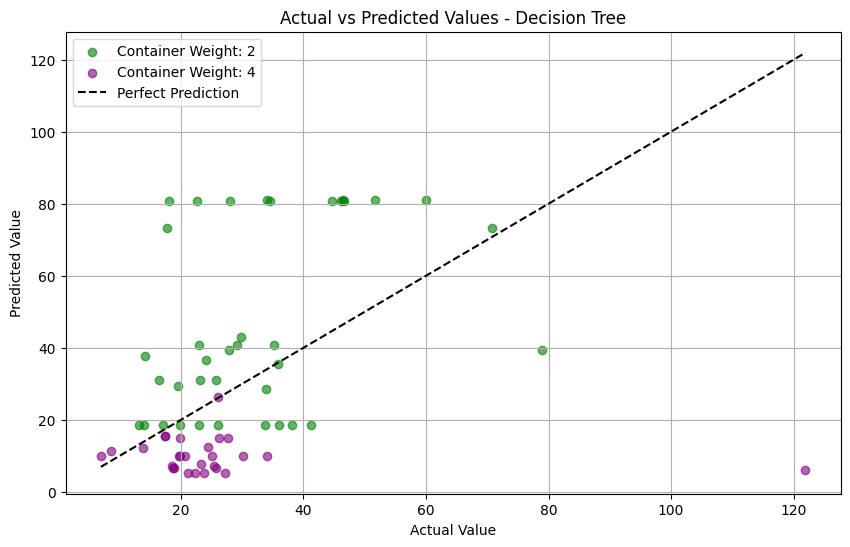


Random Forest Evaluation Metrics:
Mean Squared Error (MSE): 398.9677
Root Mean Squared Error (RMSE): 19.9742
R-squared (R²): -0.2838
Root Mean Squared Percentage Error (RMSPE): 62.5473%


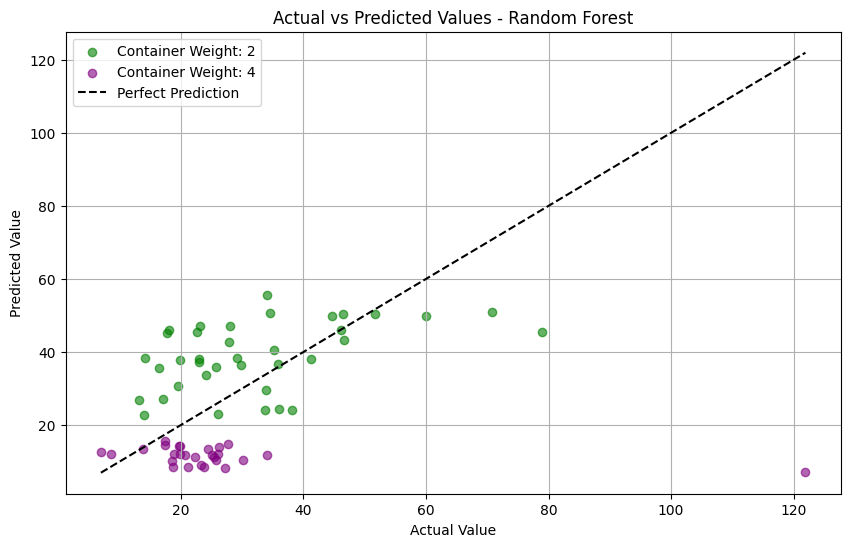


Gradient Boosting Evaluation Metrics:
Mean Squared Error (MSE): 396.9903
Root Mean Squared Error (RMSE): 19.9246
R-squared (R²): -0.2774
Root Mean Squared Percentage Error (RMSPE): 65.6818%


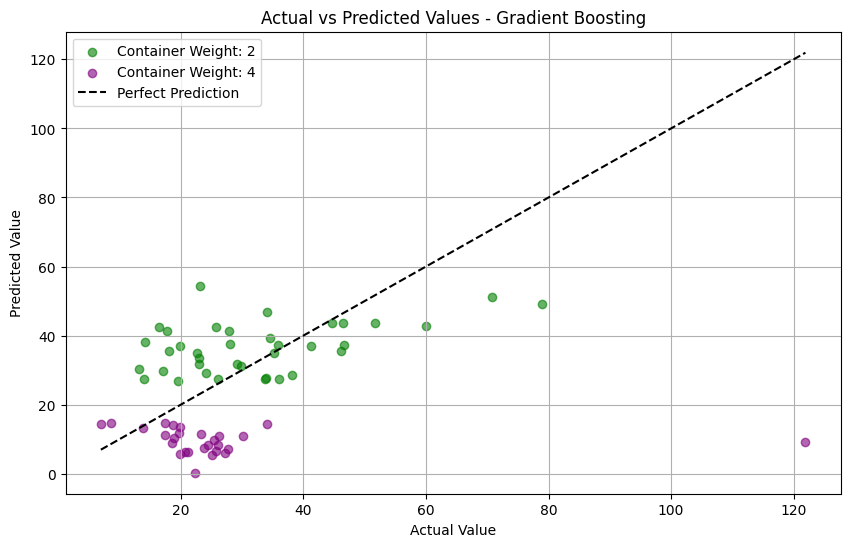


K-Nearest Neighbors Evaluation Metrics:
Mean Squared Error (MSE): 432.8618
Root Mean Squared Error (RMSE): 20.8053
R-squared (R²): -0.3929
Root Mean Squared Percentage Error (RMSPE): 57.5215%


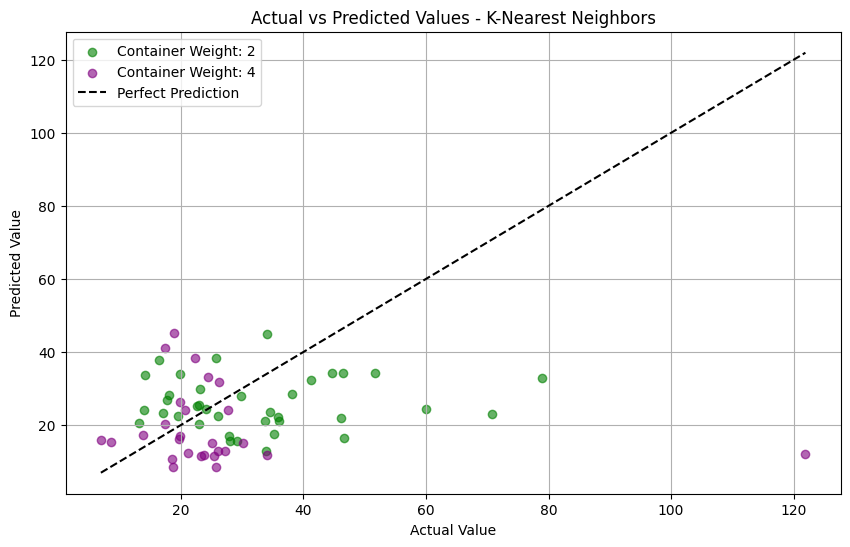

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming you have already defined your models and results above
# color_map = {
#     0: 'blue',
#     1: 'orange',
#     2: 'green',
#     3: 'red',
#     4: 'purple'
# }
color_map = {
    0: 'blue',    # For 7.7
    1: 'orange',  # For 10.6
    2: 'green',   # For 10.9
    3: 'red',     # For 12.7
    4: 'purple',  # For 19.8
    5: 'cyan'     # For 359
}
# Store evaluation results
results = {}

for model_name, model in models.items():
    # Fit the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

    # Store results in a dictionary
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R^2': r2,
        'RMSPE': rmspe,
        'Predictions': y_pred
    }

    # Print evaluation metrics for the model
    print(f"\n{model_name} Evaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R²): {r2:.4f}")
    print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

    comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Container_Weight': X_test['Container_Weight']})
    
    # Plotting Actual vs Predicted with Container Weights
    plt.figure(figsize=(10, 6))

    for weight, group in comparison_df.groupby('Container_Weight'):
        plt.scatter(group['Actual'], group['Predicted'], 
                    label=f'Container Weight: {weight}', 
                    color=color_map[weight], 
                    alpha=0.6)
# Assuming you use the updated color mapping provided above
# for weight, group in comparison_df.groupby('Container_Weight'):
#     plt.scatter(group['Actual'], group['Predicted'], 
#                 label=f'Container Weight: {weight}', 
#                 color=color_map[weight], 
#                 alpha=0.6)
    plt.plot([comparison_df['Actual'].min(), comparison_df['Actual'].max()],
             [comparison_df['Actual'].min(), comparison_df['Actual'].max()],
             color='black', ls='--', label='Perfect Prediction')

    plt.xlabel('Actual Value')
    plt.ylabel('Predicted Value')
    plt.title(f'Actual vs Predicted Values - {model_name}')
    plt.legend()
    plt.grid()
    plt.show()

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

# Assuming df is your DataFrame that contains 'Container_Weight' and your feature columns
# Mapping container weights to classes
df["Container_Weight"] = df["Container_Weight"].map({
    7.7: 0,
    10.6: 1,
    10.9: 1,  
    12.7: 2,
    19.8: 3,
    359: 4
})

# Assuming X_train and y_train are defined properly from your df DataFrame
# Define features and target variable
  # Replace with your actual target column name

# Store results for all model evaluations
overall_results = {}

# Get unique container weight classes
weight_classes = df["Container_Weight"].unique()

for category in weight_classes:
    # Filter data based on container weight class
    mask = df["Container_Weight"] == category
    X_filtered = X_train[mask]
    y_filtered = y_train[mask]

    if len(y_filtered) == 0:
        print(f"No data available for container weight category: {category}.")
        continue

    print(f"Training models for container weight category: {category}...")

    # Define your models
    models = {
        "Linear Regression": LinearRegression(),
        "Support Vector Regression": SVR(kernel='rbf'),
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
        "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    }

    # Store evaluation results for this category
    results = {}

for category in weight_classes:
    # Filter data based on container weight class
    filtered_data = df[df["Container_Weight"] == category]
    
    # Check if the filtered data is not empty
    if len(filtered_data) == 0:
        print(f"No data available for container weight category: {category}.")
        continue

    # Split filtered data into features and target
    X_filtered = filtered_data[feature_columns]
    y_filtered = filtered_data[target_column]

    print(f"Training models for container weight category: {category}...")

    # Define your models
    models = {
        "Linear Regression": LinearRegression(),
        "Support Vector Regression": SVR(kernel='rbf'),
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
        "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    }

    # Store evaluation results for this category
    results = {}

    for model_name, model in models.items():
        # Fit the model
        model.fit(X_filtered, y_filtered)

        # Make predictions using the filtered data
        y_pred = model.predict(X_filtered)  # Using the same filtered data for prediction

        # Calculate evaluation metrics
        mse = mean_squared_error(y_filtered, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_filtered, y_pred)
        rmspe = np.sqrt(np.mean(((y_filtered - y_pred) / y_filtered) ** 2)) * 100  # Percentage error

        # Store results in a dictionary
        results[model_name] = {
            'MSE': mse,
            'RMSE': rmse,
            'R^2': r2,
            'RMSPE': rmspe,
            'Predictions': y_pred
        }

        # Print evaluation metrics for the model
        print(f"\n{model_name} Evaluation Metrics for Container Weight Category {category}:")
        print(f"Mean Squared Error (MSE): {mse:.4f}")
        print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"R-squared (R²): {r2:.4f}")
        print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

        # Create a comparison DataFrame for the first few rows
        comparison_df = pd.DataFrame({'Actual': y_filtered, 'Predicted': y_pred})
        print(comparison_df.head(5))

        # Plotting Actual vs Predicted
        plt.figure(figsize=(10, 6))
        plt.scatter(y_filtered, y_pred, label=model_name, alpha=0.6)
        plt.plot([y_filtered.min(), y_filtered.max()], [y_filtered.min(), y_filtered.max()], color='red', ls='--', label='Perfect Prediction')
        plt.xlabel('Actual Value')
        plt.ylabel('Predicted Value')
        plt.title(f'Actual vs Predicted Values - {model_name} (Container Weight {category})')
        plt.legend()
        plt.grid()
        plt.show()
    
    # Store results for overall overview
    overall_results[category] = results

print("Model evaluations completed for all container weight categories.")
    

/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_18467/4077206475.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Container_Weight"] = df["Container_Weight"].map({
/var/folders/s7/ddngkscs167c_65wscck142m0000gr/T/ipykernel_18467/4077206475.py:35: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_filtered = X_train[mask]


IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

In [26]:
df["Container_Weight"]

241     NaN
242     NaN
243     NaN
244     NaN
245     NaN
         ..
79927   NaN
79928   NaN
79929   NaN
79930   NaN
79931   NaN
Name: Container_Weight, Length: 5345, dtype: float64


Linear Regression Evaluation Metrics:
Mean Squared Error (MSE): 162.3618
Root Mean Squared Error (RMSE): 12.7421
R-squared (R²): -1.2415
Root Mean Squared Percentage Error (RMSPE): 40.7277%
        Actual  Predicted
96   16.567460  14.051648
97   17.261905  12.886714
98   20.535714  13.358107
99   21.230159  13.011337
100  14.583333  12.664566


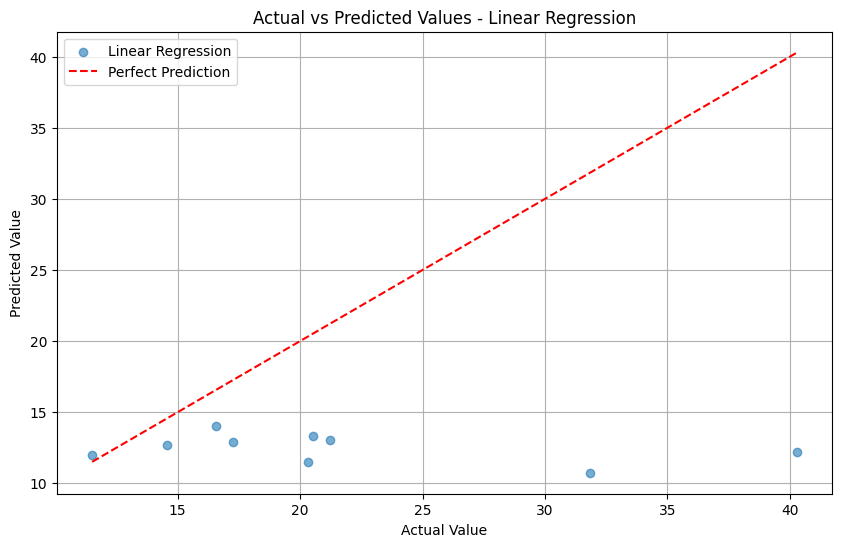


Support Vector Regression Evaluation Metrics:
Mean Squared Error (MSE): 139.1040
Root Mean Squared Error (RMSE): 11.7942
R-squared (R²): -0.9204
Root Mean Squared Percentage Error (RMSPE): 38.2903%
        Actual  Predicted
96   16.567460  13.410097
97   17.261905  13.196423
98   20.535714  13.201481
99   21.230159  13.096430
100  14.583333  12.992666


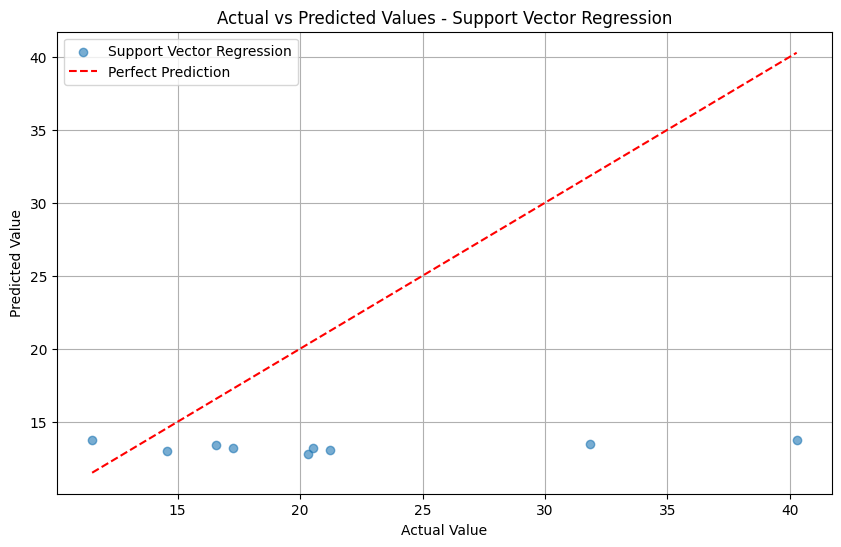


Decision Tree Evaluation Metrics:
Mean Squared Error (MSE): 151.6369
Root Mean Squared Error (RMSE): 12.3141
R-squared (R²): -1.0934
Root Mean Squared Percentage Error (RMSPE): 41.1943%
        Actual  Predicted
96   16.567460  12.698413
97   17.261905  11.706349
98   20.535714  12.698413
99   21.230159  12.698413
100  14.583333  12.698413


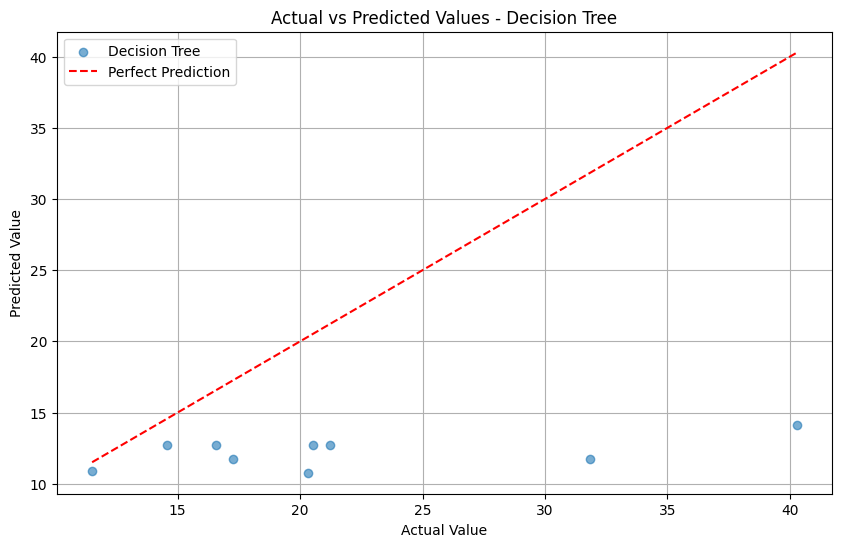


Random Forest Evaluation Metrics:
Mean Squared Error (MSE): 119.9906
Root Mean Squared Error (RMSE): 10.9540
R-squared (R²): -0.6565
Root Mean Squared Percentage Error (RMSPE): 35.3964%
        Actual  Predicted
96   16.567460  22.757737
97   17.261905  18.636442
98   20.535714  20.492146
99   21.230159  20.487205
100  14.583333  19.575758


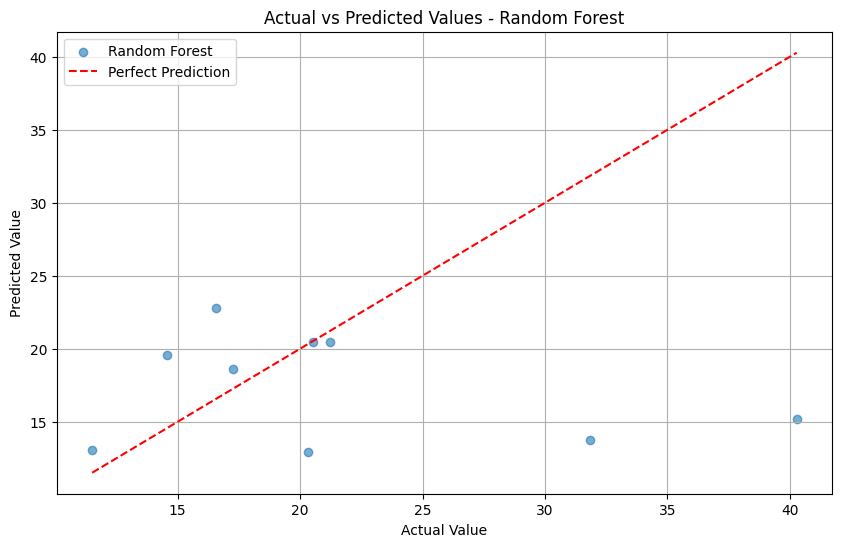


Gradient Boosting Evaluation Metrics:
Mean Squared Error (MSE): 187.5541
Root Mean Squared Error (RMSE): 13.6950
R-squared (R²): -1.5893
Root Mean Squared Percentage Error (RMSPE): 42.3771%
        Actual  Predicted
96   16.567460  18.208846
97   17.261905  13.920696
98   20.535714  16.405083
99   21.230159  16.493246
100  14.583333  17.799038


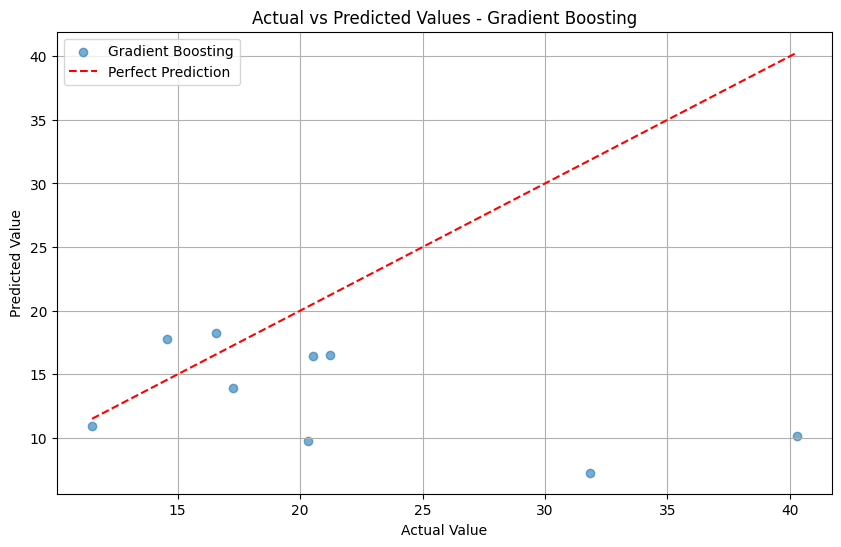


K-Nearest Neighbors Evaluation Metrics:
Mean Squared Error (MSE): 99.6139
Root Mean Squared Error (RMSE): 9.9807
R-squared (R²): -0.3752
Root Mean Squared Percentage Error (RMSPE): 29.8604%
        Actual  Predicted
96   16.567460  18.698711
97   17.261905  17.927960
98   20.535714  18.313178
99   21.230159  17.042396
100  14.583333  16.627376


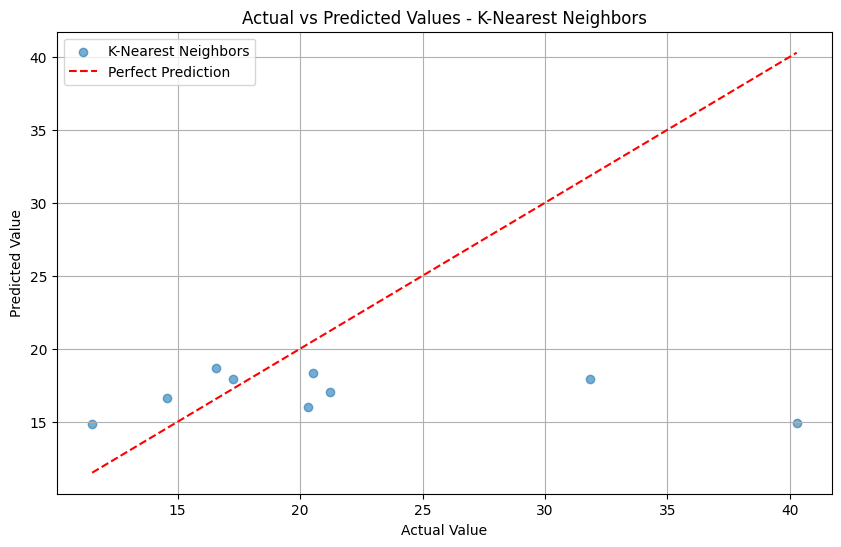

Model evaluations completed for container weight category: 1


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor


# Models to evaluate
models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regression": SVR(kernel='rbf'),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
}

# # Define the category to filter
# category = 2  # Example category to filter by
# train_size = int(0.8 * len(grouped_data))  # 80% of the data for training
# X_train = X.iloc[:train_size]
# y_train = y.iloc[:train_size]
# X_test = X.iloc[train_size:]
# y_test = y.iloc[train_size:]
# # Filter X_train based on the Container_Weight column
# filtered_X = X_train[X_train["Container_Weight"] == category]
# print(filtered_X)
# # If you also want to filter the corresponding target variable y_train
# filtered_y = y_train.loc[filtered_X.index]
# print(filtered_y)
# filtered_X_test = X_test[X_test["Container_Weight"] == category]
# filtered_y_test = y_test.loc[filtered_X_test.index]
# print(filtered_X_test)
# print(filtered_y_test)
category = 1  # Example category to filter by

# Step 1: Filter X and y based on the Container_Weight column
filtered_X = X[X["Container_Weight"] == category]
filtered_y = y[filtered_X.index]  # Get matching y values using the indices of filtered_X

# Now filtered_X contains only the rows where Container_Weight equals the category
# filtered_y corresponds to these rows

# Step 2: Split the filtered data into train and test sets
train_size = int(0.8 * len(filtered_X))  # 80% for training
X_train = filtered_X.iloc[:train_size]
y_train = filtered_y.iloc[:train_size]
X_test = filtered_X.iloc[train_size:]
y_test = filtered_y.iloc[train_size:]

# Check if there are any rows after filtering
if filtered_X.empty or filtered_y.empty:
    print(f"No data available for container weight category: {category}.")
else:
    # Store evaluation results for this category
    results = {}

    for model_name, model in models.items():
        # Fit the model
        model.fit(X_train, y_train)

        # Make predictions using the filtered data
        y_pred = model.predict(X_test)  # Using the same filtered data for prediction

          # Calculate evaluation metrics
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        rmspe = np.sqrt(np.mean(((y_test - y_pred) / y_test) ** 2)) * 100  # Percentage error

    # Store results in a dictionary
        results[model_name] = {
            'MSE': mse,
            'RMSE': rmse,
            'R^2': r2,
            'RMSPE': rmspe,
            'Predictions': y_pred
        }

    # Print evaluation metrics for the model
        print(f"\n{model_name} Evaluation Metrics:")
        print(f"Mean Squared Error (MSE): {mse:.4f}")
        print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"R-squared (R²): {r2:.4f}")
        print(f"Root Mean Squared Percentage Error (RMSPE): {rmspe:.4f}%")

    # Create a comparison DataFrame for the first few rows
        comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
        print(comparison_df.head(5))

    # Plotting Actual vs Predicted
        plt.figure(figsize=(10, 6))
        plt.scatter(y_test, y_pred, label=model_name, alpha=0.6)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', ls='--', label='Perfect Prediction')
        plt.xlabel('Actual Value')
        plt.ylabel('Predicted Value')
        plt.title(f'Actual vs Predicted Values - {model_name}')
        plt.legend()
        plt.grid()
        plt.show()

print("Model evaluations completed for container weight category:", category)